# IMPORTS & SETUP

In [1]:

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
import torchvision.transforms as transforms
import torchvision.datasets as datasets
from torch.optim.lr_scheduler import ReduceLROnPlateau

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize
import time
import os
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Check GPU availability
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if device.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"CUDA version: {torch.version.cuda}")
    torch.cuda.manual_seed(42)

Using device: cuda
GPU: Tesla T4
CUDA version: 12.4


# Data Preparation with Augmentation

In [2]:

class DataPreprocessor:
    def __init__(self, data_path, img_size=128, batch_size=32):
        self.data_path = data_path
        self.img_size = img_size
        self.batch_size = batch_size
        
    def get_transforms(self):
        """Define training and validation transforms"""
        train_transforms = transforms.Compose([
            transforms.Resize((self.img_size, self.img_size)),
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomRotation(degrees=10),
            transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
            transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                               std=[0.229, 0.224, 0.225])
        ])
        
        val_transforms = transforms.Compose([
            transforms.Resize((self.img_size, self.img_size)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                               std=[0.229, 0.224, 0.225])
        ])
        
        return train_transforms, val_transforms
    
    def prepare_datasets(self):
        """Prepare datasets and dataloaders"""
        train_transforms, val_transforms = self.get_transforms()
        
        # Load full dataset
        full_dataset = datasets.ImageFolder(
            root=self.data_path,
            transform=train_transforms  # Use train transforms initially
        )
        
        # Get class names
        self.class_names = full_dataset.classes
        print(f"Dataset classes: {self.class_names}")
        print(f"Total samples: {len(full_dataset)}")
        
        # Split dataset (70% train, 15% validation, 15% test)
        train_size = int(0.7 * len(full_dataset))
        val_size = int(0.15 * len(full_dataset))
        test_size = len(full_dataset) - train_size - val_size
        
        # Split the dataset
        train_dataset, val_test_dataset = random_split(
            full_dataset, [train_size, val_size + test_size]
        )
        
        val_dataset, test_dataset = random_split(
            val_test_dataset, [val_size, test_size]
        )
        
        # Apply validation transforms to val and test datasets
        val_dataset.dataset.transform = val_transforms
        test_dataset.dataset.transform = val_transforms
        
        print(f"Training samples: {len(train_dataset)}")
        print(f"Validation samples: {len(val_dataset)}")
        print(f"Test samples: {len(test_dataset)}")
        
        return train_dataset, val_dataset, test_dataset
    
    def prepare_dataloaders(self):
        """Prepare dataloaders with GPU optimization"""
        train_dataset, val_dataset, test_dataset = self.prepare_datasets()
        
        train_loader = DataLoader(
            train_dataset, 
            batch_size=self.batch_size, 
            shuffle=True,
            num_workers=2,
            pin_memory=True if device.type == 'cuda' else False
        )
        
        val_loader = DataLoader(
            val_dataset, 
            batch_size=self.batch_size, 
            shuffle=False,
            num_workers=2,
            pin_memory=True if device.type == 'cuda' else False
        )
        
        test_loader = DataLoader(
            test_dataset, 
            batch_size=self.batch_size, 
            shuffle=False,
            num_workers=2,
            pin_memory=True if device.type == 'cuda' else False
        )
        
        return train_loader, val_loader, test_loader

# Build Custom CNN Model

In [3]:

class CustomPlantCNN(nn.Module):
    def __init__(self, num_classes=16, dropout_rate=0.5):
        super(CustomPlantCNN, self).__init__()
        
        # Convolutional Block 1
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        
        # Convolutional Block 2
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        
        # Convolutional Block 3
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        
        # Convolutional Block 4
        self.conv4 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        self.bn4 = nn.BatchNorm2d(256)
        
        # Global Average Pooling
        self.global_avg_pool = nn.AdaptiveAvgPool2d((1, 1))
        
        # Fully Connected Layers
        self.fc1 = nn.Linear(256, 512)
        self.fc2 = nn.Linear(512, num_classes)
        
        # Regularization
        self.dropout = nn.Dropout(dropout_rate)
        self.pool = nn.MaxPool2d(2, 2)
        
    def forward(self, x):
        # Block 1: Conv -> BN -> ReLU -> Pool
        x = self.pool(torch.relu(self.bn1(self.conv1(x))))
        
        # Block 2: Conv -> BN -> ReLU -> Pool
        x = self.pool(torch.relu(self.bn2(self.conv2(x))))
        
        # Block 3: Conv -> BN -> ReLU -> Pool
        x = self.pool(torch.relu(self.bn3(self.conv3(x))))
        
        # Block 4: Conv -> BN -> ReLU -> Pool
        x = self.pool(torch.relu(self.bn4(self.conv4(x))))
        
        # Global Average Pooling
        x = self.global_avg_pool(x)
        x = x.view(x.size(0), -1)
        
        # Fully connected layers
        x = torch.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        
        return x

# Model Training

In [4]:

class PlantTrainer:
    def __init__(self, model, train_loader, val_loader, criterion, optimizer, device):
        self.model = model
        self.train_loader = train_loader
        self.val_loader = val_loader
        self.criterion = criterion
        self.optimizer = optimizer
        self.device = device
        
        self.train_losses = []
        self.val_losses = []
        self.train_accuracies = []
        self.val_accuracies = []
        
    def train_epoch(self):
        """Train for one epoch"""
        self.model.train()
        running_loss = 0.0
        correct = 0
        total = 0
        
        pbar = tqdm(self.train_loader, desc='Training')
        for batch_idx, (data, targets) in enumerate(pbar):
            data, targets = data.to(self.device), targets.to(self.device)
            
            # Forward pass
            outputs = self.model(data)
            loss = self.criterion(outputs, targets)
            
            # Backward pass and optimize
            self.optimizer.zero_grad()
            loss.backward()
            self.optimizer.step()
            
            # Statistics
            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += targets.size(0)
            correct += predicted.eq(targets).sum().item()
            
            # Update progress bar
            pbar.set_postfix({
                'Loss': f'{loss.item():.4f}',
                'Acc': f'{100.*correct/total:.2f}%'
            })
        
        epoch_loss = running_loss / len(self.train_loader)
        epoch_acc = 100. * correct / total
        
        return epoch_loss, epoch_acc
    
    def validate_epoch(self):
        """Validate for one epoch"""
        self.model.eval()
        running_loss = 0.0
        correct = 0
        total = 0
        
        with torch.no_grad():
            for data, targets in self.val_loader:
                data, targets = data.to(self.device), targets.to(self.device)
                
                outputs = self.model(data)
                loss = self.criterion(outputs, targets)
                
                running_loss += loss.item()
                _, predicted = outputs.max(1)
                total += targets.size(0)
                correct += predicted.eq(targets).sum().item()
        
        epoch_loss = running_loss / len(self.val_loader)
        epoch_acc = 100. * correct / total
        
        return epoch_loss, epoch_acc
    
    def train(self, epochs, patience=5):
        """Full training loop with early stopping"""
        best_val_acc = 0
        patience_counter = 0
        start_time = time.time()
        
        print("Starting training...")
        for epoch in range(epochs):
            print(f'\nEpoch {epoch+1}/{epochs}')
            print('-' * 50)
            
            # Train and validate
            train_loss, train_acc = self.train_epoch()
            val_loss, val_acc = self.validate_epoch()
            
            # Store metrics
            self.train_losses.append(train_loss)
            self.val_losses.append(val_loss)
            self.train_accuracies.append(train_acc)
            self.val_accuracies.append(val_acc)
            
            print(f'Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%')
            print(f'Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%')
            
            # Early stopping check
            if val_acc > best_val_acc:
                best_val_acc = val_acc
                patience_counter = 0
                # Save best model
                torch.save(self.model.state_dict(), 'best_custom_cnn.pth')
                print(f'New best model saved! Validation Accuracy: {val_acc:.2f}%')
            else:
                patience_counter += 1
                print(f'Early stopping counter: {patience_counter}/{patience}')
                
            if patience_counter >= patience:
                print(f'Early stopping triggered after {epoch+1} epochs!')
                break
        
        training_time = time.time() - start_time
        print(f'\nTraining completed in {training_time:.2f} seconds')
        print(f'Best Validation Accuracy: {best_val_acc:.2f}%')
        
        return training_time

# Model Evaluation

In [5]:

class ModelEvaluator:
    def __init__(self, model, test_loader, device, class_names):
        self.model = model
        self.test_loader = test_loader
        self.device = device
        self.class_names = class_names
        
    def evaluate_model(self):
        """Comprehensive model evaluation"""
        self.model.eval()
        all_predictions = []
        all_targets = []
        all_probabilities = []
        test_correct = 0
        test_total = 0
        
        start_time = time.time()
        with torch.no_grad():
            for data, targets in tqdm(self.test_loader, desc='Testing'):
                data, targets = data.to(self.device), targets.to(self.device)
                
                outputs = self.model(data)
                probabilities = torch.softmax(outputs, dim=1)
                _, predicted = outputs.max(1)
                
                all_predictions.extend(predicted.cpu().numpy())
                all_targets.extend(targets.cpu().numpy())
                all_probabilities.extend(probabilities.cpu().numpy())
                
                test_total += targets.size(0)
                test_correct += predicted.eq(targets).sum().item()
        
        inference_time = time.time() - start_time
        
        # Calculate metrics
        accuracy = 100. * test_correct / test_total
        all_predictions = np.array(all_predictions)
        all_targets = np.array(all_targets)
        all_probabilities = np.array(all_probabilities)
        
        print(f'\nTest Accuracy: {accuracy:.2f}%')
        print(f'Inference Time: {inference_time:.2f} seconds')
        
        return all_predictions, all_targets, all_probabilities, accuracy, inference_time
    
    def plot_confusion_matrix(self, predictions, targets):
        """Plot confusion matrix"""
        cm = confusion_matrix(targets, predictions)
        plt.figure(figsize=(12, 10))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                   xticklabels=self.class_names,
                   yticklabels=self.class_names)
        plt.title('Confusion Matrix - Custom CNN')
        plt.xlabel('Predicted')
        plt.ylabel('Actual')
        plt.xticks(rotation=45)
        plt.yticks(rotation=0)
        plt.tight_layout()
        plt.show()
        
        return cm
    
    def plot_roc_curves(self, targets, probabilities):
        """Plot ROC curves for each class"""
        # Binarize the output
        y_test_bin = label_binarize(targets, classes=range(len(self.class_names)))
        
        # Compute ROC curve and ROC area for each class
        fpr = {}
        tpr = {}
        roc_auc = {}
        
        plt.figure(figsize=(12, 10))
        for i in range(len(self.class_names)):
            fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], probabilities[:, i])
            roc_auc[i] = auc(fpr[i], tpr[i])
            plt.plot(fpr[i], tpr[i], 
                    label=f'{self.class_names[i]} (AUC = {roc_auc[i]:.2f})')
        
        plt.plot([0, 1], [0, 1], 'k--', lw=2)
        plt.xlim([0.0, 1.0])
        plt.ylim([0.0, 1.05])
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title('Multi-class ROC Curves - Custom CNN')
        plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.grid(True)
        plt.tight_layout()
        plt.show()
        
        return roc_auc
    
    def generate_classification_report(self, predictions, targets):
        """Generate detailed classification report"""
        report = classification_report(targets, predictions, 
                                     target_names=self.class_names,
                                     output_dict=True)
        
        print("\nClassification Report:")
        print(classification_report(targets, predictions, 
                                  target_names=self.class_names))
        
        # Plot class-wise accuracy
        class_accuracies = []
        for i, class_name in enumerate(self.class_names):
            class_mask = targets == i
            if np.sum(class_mask) > 0:
                class_acc = np.mean(predictions[class_mask] == i) * 100
                class_accuracies.append(class_acc)
            else:
                class_accuracies.append(0)
        
        plt.figure(figsize=(12, 6))
        plt.bar(range(len(self.class_names)), class_accuracies)
        plt.xlabel('Classes')
        plt.ylabel('Accuracy (%)')
        plt.title('Class-wise Accuracy - Custom CNN')
        plt.xticks(range(len(self.class_names)), self.class_names, rotation=45)
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()
        
        return report, class_accuracies

# Configuration and Main Execution

In [6]:

# Configuration
DATA_PATH = "/kaggle/input/rare-and-endangered-medicinal-plants-in-bangladesh/Raw-Images"
IMG_SIZE = 128
BATCH_SIZE = 32
LEARNING_RATE = 0.001
EPOCHS = 50
PATIENCE = 5

print("Custom CNN Model for Medicinal Plants Classification")
print("=" * 60)

# Step 1: Data Preparation
print("\n1. Preparing Data...")
preprocessor = DataPreprocessor(DATA_PATH, IMG_SIZE, BATCH_SIZE)
train_loader, val_loader, test_loader = preprocessor.prepare_dataloaders()
class_names = preprocessor.class_names

Custom CNN Model for Medicinal Plants Classification

1. Preparing Data...
Dataset classes: ['type_1', 'type_10', 'type_11', 'type_12', 'type_13', 'type_14', 'type_15', 'type_16', 'type_2', 'type_3', 'type_4', 'type_5', 'type_6', 'type_7', 'type_8', 'type_9']
Total samples: 3494
Training samples: 2445
Validation samples: 524
Test samples: 525


# Model Initialization and Training Setup

In [7]:

print("\n2. Initializing Custom CNN Model...")
model = CustomPlantCNN(num_classes=len(class_names), dropout_rate=0.5)
model = model.to(device)

# Print model summary
print(f"Model initialized with {sum(p.numel() for p in model.parameters()):,} parameters")

# Step 3: Training Setup
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)
scheduler = ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3, verbose=True)


2. Initializing Custom CNN Model...
Model initialized with 529,168 parameters


# Model Training

In [8]:

# Step 4: Training
print("\n3. Starting Training...")
trainer = PlantTrainer(model, train_loader, val_loader, criterion, optimizer, device)
training_time = trainer.train(EPOCHS, PATIENCE)


3. Starting Training...
Starting training...

Epoch 1/50
--------------------------------------------------


Training: 100%|██████████| 77/77 [00:13<00:00,  5.76it/s, Loss=1.4400, Acc=37.18%]


Train Loss: 1.9210, Train Acc: 37.18%
Val Loss: 1.2367, Val Acc: 59.73%
New best model saved! Validation Accuracy: 59.73%

Epoch 2/50
--------------------------------------------------


Training: 100%|██████████| 77/77 [00:07<00:00, 10.31it/s, Loss=1.2680, Acc=55.87%]


Train Loss: 1.2662, Train Acc: 55.87%
Val Loss: 0.9995, Val Acc: 67.18%
New best model saved! Validation Accuracy: 67.18%

Epoch 3/50
--------------------------------------------------


...

Train Loss: 0.3186, Train Acc: 88.51%
Val Loss: 0.5466, Val Acc: 81.49%
Early stopping counter: 3/5

Epoch 20/50
--------------------------------------------------


Training: 100%|██████████| 77/77 [00:07<00:00, 10.43it/s, Loss=0.3199, Acc=90.31%]


Train Loss: 0.2998, Train Acc: 90.31%
Val Loss: 0.4387, Val Acc: 85.11%
Early stopping counter: 4/5

Epoch 21/50
--------------------------------------------------


Training: 100%|██████████| 77/77 [00:07<00:00, 10.46it/s, Loss=0.1775, Acc=89.82%]


Train Loss: 0.3015, Train Acc: 89.82%
Val Loss: 0.3229, Val Acc: 87.98%
Early stopping counter: 5/5
Early stopping triggered after 21 epochs!

Training completed in 197.62 seconds
Best Validation Accuracy: 89.69%


# Model Evaluation

In [9]:

# Step 5: Load Best Model and Evaluate
print("\n4. Loading Best Model and Evaluating...")
model.load_state_dict(torch.load('best_custom_cnn.pth'))

evaluator = ModelEvaluator(model, test_loader, device, class_names)
predictions, targets, probabilities, test_accuracy, inference_time = evaluator.evaluate_model()


4. Loading Best Model and Evaluating...


Testing: 100%|██████████| 17/17 [00:02<00:00,  5.86it/s]


Test Accuracy: 87.24%
Inference Time: 2.90 seconds


# Confusion Matrix


5. Generating Evaluation Reports...


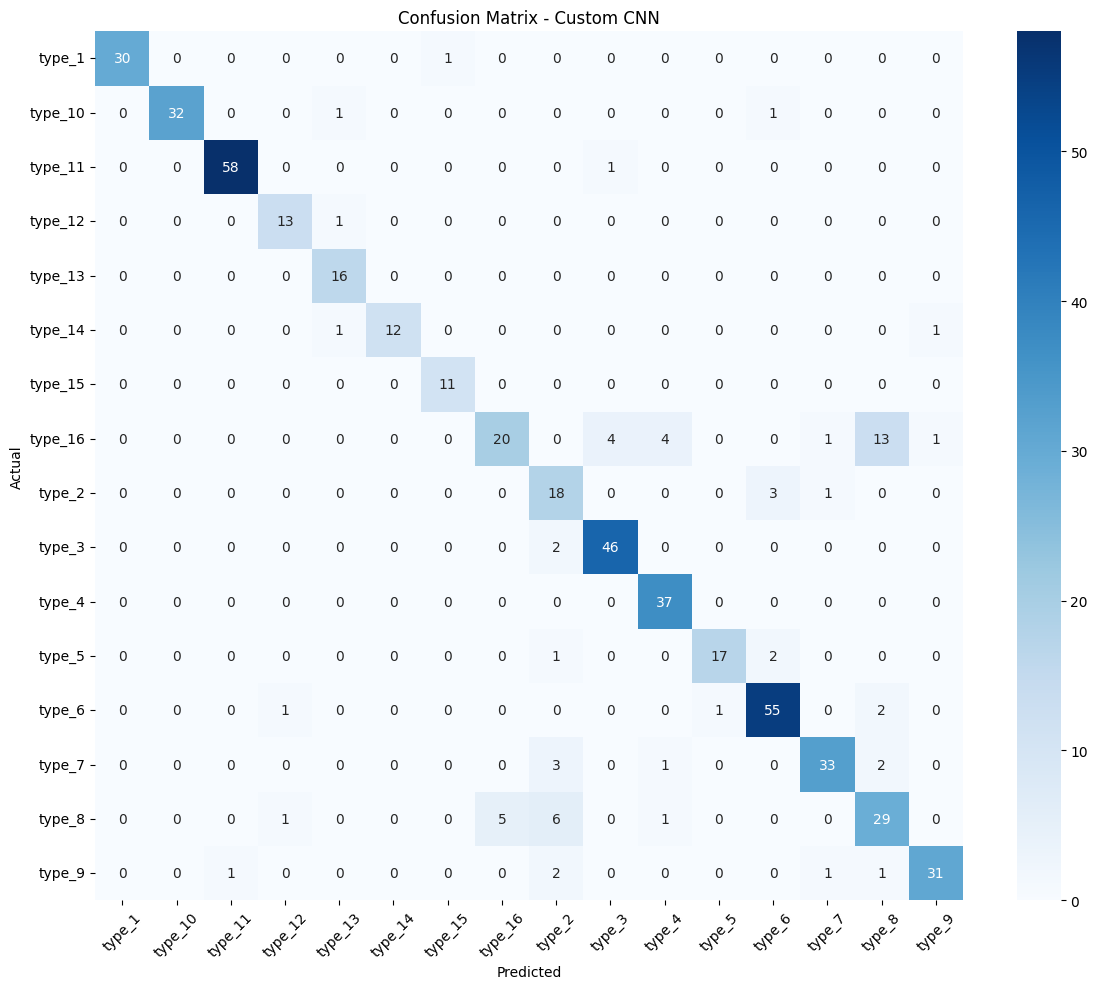

In [10]:

print("\n5. Generating Evaluation Reports...")

# Confusion Matrix
cm = evaluator.plot_confusion_matrix(predictions, targets)


# ROC Curves and AUC

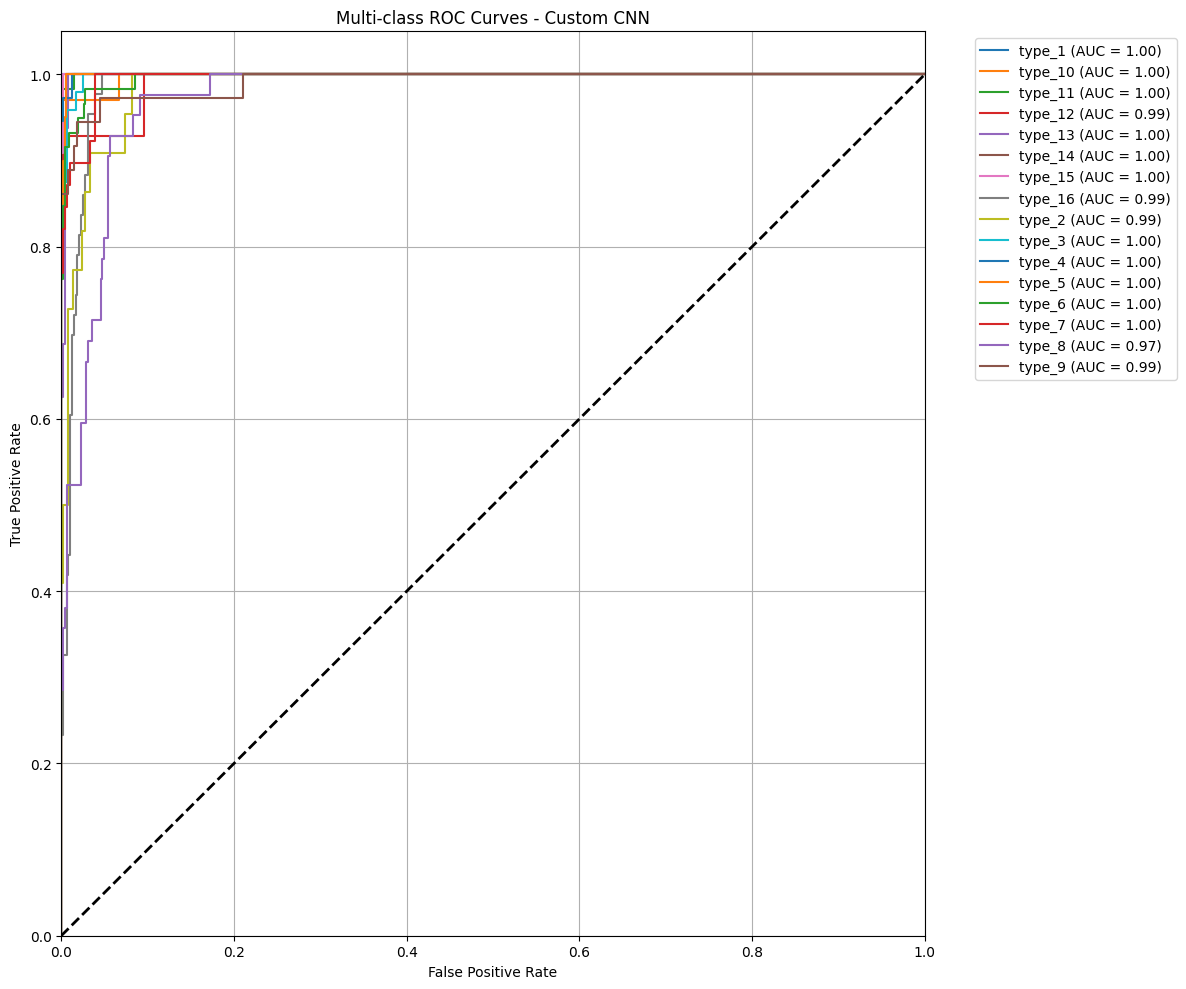

In [11]:
# ROC Curves
roc_auc = evaluator.plot_roc_curves(targets, probabilities)

# Classification Report


Classification Report:
              precision    recall  f1-score   support

      type_1       1.00      0.97      0.98        31
     type_10       1.00      0.94      0.97        34
     type_11       0.98      0.98      0.98        59
     type_12       0.87      0.93      0.90        14
     type_13       0.84      1.00      0.91        16
     type_14       1.00      0.86      0.92        14
     type_15       0.92      1.00      0.96        11
     type_16       0.80      0.47      0.59        43
      type_2       0.56      0.82      0.67        22
      type_3       0.90      0.96      0.93        48
      type_4       0.86      1.00      0.92        37
      type_5       0.94      0.85      0.89        20
      type_6       0.90      0.93      0.92        59
      type_7       0.92      0.85      0.88        39
      type_8       0.62      0.69      0.65        42
      type_9       0.94      0.86      0.90        36

    accuracy                           0.87       525
  

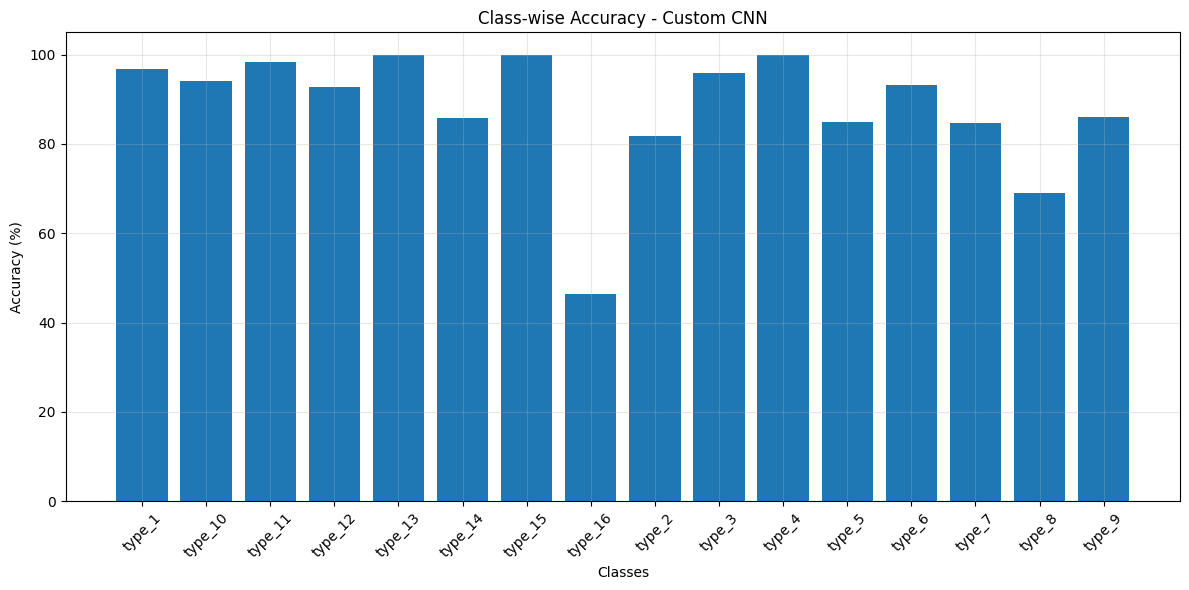

In [12]:
# Classification Report
report, class_accuracies = evaluator.generate_classification_report(predictions, targets)

# Training History and Final Summary

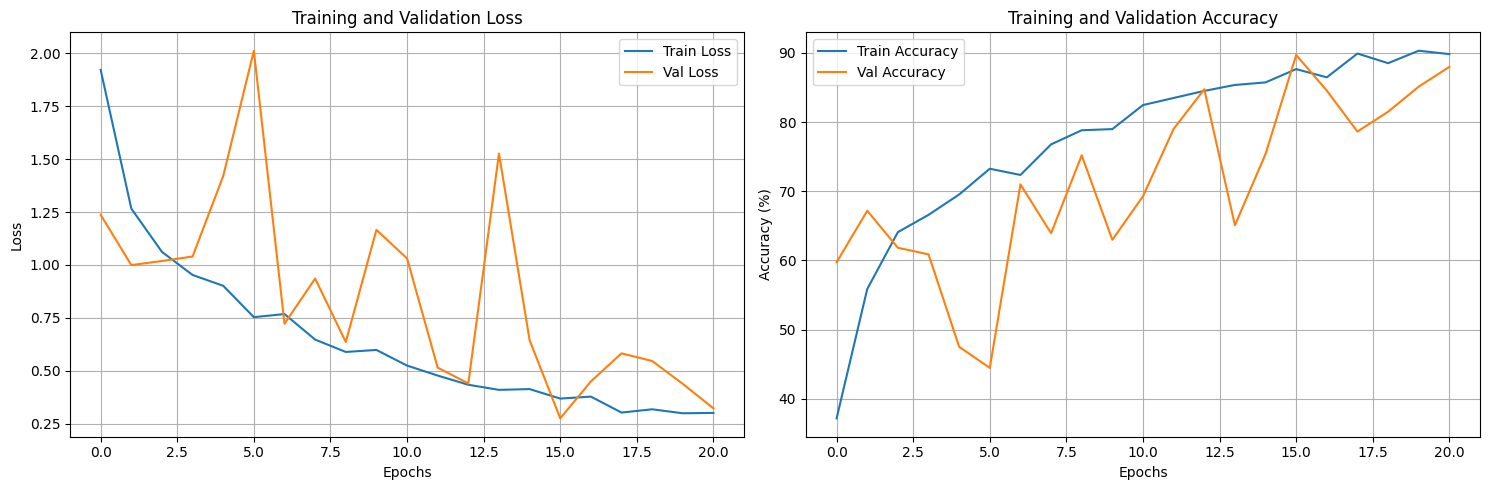


FINAL RESULTS SUMMARY - CUSTOM CNN MODEL
Training Time: 197.62 seconds
Inference Time: 2.90 seconds
Test Accuracy: 87.24%
Number of Parameters: 529,168
Best Model Saved: best_custom_cnn.pth

Results saved to 'custom_cnn_results.csv'


In [13]:

# Training History
plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
plt.plot(trainer.train_losses, label='Train Loss')
plt.plot(trainer.val_losses, label='Val Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(trainer.train_accuracies, label='Train Accuracy')
plt.plot(trainer.val_accuracies, label='Val Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# Step 7: Final Summary
print("\n" + "=" * 60)
print("FINAL RESULTS SUMMARY - CUSTOM CNN MODEL")
print("=" * 60)
print(f"Training Time: {training_time:.2f} seconds")
print(f"Inference Time: {inference_time:.2f} seconds")
print(f"Test Accuracy: {test_accuracy:.2f}%")
print(f"Number of Parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"Best Model Saved: best_custom_cnn.pth")

# Save results to CSV
results_df = pd.DataFrame({
    'Metric': ['Training Time (s)', 'Inference Time (s)', 'Test Accuracy (%)', 'Parameters'],
    'Value': [training_time, inference_time, test_accuracy, sum(p.numel() for p in model.parameters())]
})
results_df.to_csv('custom_cnn_results.csv', index=False)
print("\nResults saved to 'custom_cnn_results.csv'")